# Loading the data and all imports

In [3]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("data/kalshi_w_macro_markets.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'kalshi_w_macro_markets.csv'

In [ ]:
df.head()

,Date,Close,High,Low,Open,Volume,Day Change %,3m_treasury,2yr_treasury,10yr_treasury,...,VIX,fed_funds_rate,Overnight_Return,Overnight_Volatility,Futures_Last_Price,exp_rate,volume_C25,volume_H0,volume_H25,mean_H0
0,2025-07-30,6362.899902,6396.540039,6336.379883,6381.229980,5375070000,-0.287250,4.41,3.94,4.38,...,15.48,4.33,-0.000506,0.000354,6412.25,0.000000,0.0,0.0,0.0,0.000000
1,2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461,4.41,3.94,4.37,...,16.72,4.33,0.006948,0.002083,6456.75,-1.000000,30322.0,104894.0,93.0,0.115385
2,2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646,4.35,3.69,4.23,...,20.38,4.33,-0.022168,0.002764,6314.75,-0.174537,749266.0,1152393.0,11073.0,-0.672131
3,2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455,4.35,3.69,4.22,...,17.52,4.33,0.006290,0.000658,6304.00,0.081891,72574.0,85485.0,7937.0,0.000000
4,2025-08-05,6299.189941,6346.000000,6289.370117,6336.629883,5517410000,-0.590849,4.34,3.72,4.22,...,17.85,4.33,0.009776,0.001891,6365.75,-0.652510,169801.0,196020.0,108.0,-0.105263


In [ ]:
# df = df.drop(columns=["mean_C25", "mean_H25", "exp_rate_open_interest"])
df = df.fillna(0)
df.head()

,Date,Close,High,Low,Open,Volume,Day Change %,3m_treasury,2yr_treasury,10yr_treasury,...,VIX,fed_funds_rate,Overnight_Return,Overnight_Volatility,Futures_Last_Price,exp_rate,volume_C25,volume_H0,volume_H25,mean_H0
0,2025-07-30,6362.899902,6396.540039,6336.379883,6381.229980,5375070000,-0.287250,4.41,3.94,4.38,...,15.48,4.33,-0.000506,0.000354,6412.25,0.000000,0.0,0.0,0.0,0.000000
1,2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461,4.41,3.94,4.37,...,16.72,4.33,0.006948,0.002083,6456.75,-1.000000,30322.0,104894.0,93.0,0.115385
2,2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646,4.35,3.69,4.23,...,20.38,4.33,-0.022168,0.002764,6314.75,-0.174537,749266.0,1152393.0,11073.0,-0.672131
3,2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455,4.35,3.69,4.22,...,17.52,4.33,0.006290,0.000658,6304.00,0.081891,72574.0,85485.0,7937.0,0.000000
4,2025-08-05,6299.189941,6346.000000,6289.370117,6336.629883,5517410000,-0.590849,4.34,3.72,4.22,...,17.85,4.33,0.009776,0.001891,6365.75,-0.652510,169801.0,196020.0,108.0,-0.105263


In [ ]:
target_col = "Day Change %"

X = df.drop(columns=["Date", target_col])
y = df[target_col]

print(X.shape)
print(y.shape)

(154, 19)
(154,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Linear Regression Model

In [ ]:
linear_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)
linear_model.fit(X_train, y_train)

y_hat_train = linear_model.predict(X_train)
y_hat_test = linear_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_hat_train)
test_mse = mean_squared_error(y_test, y_hat_test)

print("Linear Regression")
print("train_mse:", train_mse)
print("test_mse:", test_mse)

Linear Regression
train_mse: 0.0002363762177756273
test_mse: 0.0003169875288916838


inspect the coefficients and the actual v. predicted 

In [ ]:
coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": linear_model.named_steps["regressor"].coef_,
    }
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
coef_df.head(15)


,feature,coefficient,abs_coefficient
0,Close,2.817549,2.817549
3,Open,-2.778207,2.778207
7,10yr_treasury,-0.014457,0.014457
8,yield_curve,0.013689,0.013689
6,2yr_treasury,0.013298,0.013298
2,Low,-0.010365,0.010365
1,High,0.009004,0.009004
10,fed_funds_rate,0.004818,0.004818
13,Futures_Last_Price,-0.002906,0.002906
17,volume_H25,0.002224,0.002224


actual v predicted preview 

In [ ]:
results_preview = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_hat_test
})

results_preview.head(15)

,Actual,Predicted
15,-0.169205,-0.159888
94,0.578610,0.590767
152,1.435721,1.435042
105,0.031000,0.032982
109,0.143058,0.146058
65,-0.556230,-0.574106
18,-0.284160,-0.270827
45,-0.237100,-0.237062
36,0.259511,0.250639
55,-0.896248,-0.883692


# Lasso Model

In [ ]:
from sklearn.linear_model import LassoCV

lasso_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LassoCV(cv=5, random_state=42)),
    ]
)
lasso_model.fit(X_train, y_train)

In [ ]:
y_hat_train_lasso = lasso_model.predict(X_train)
y_hat_test_lasso = lasso_model.predict(X_test)

lasso_train_mse = mean_squared_error(y_train, y_hat_train_lasso)
lasso_test_mse = mean_squared_error(y_test, y_hat_test_lasso)

print("Lasso Regression")
print("train_mse:", lasso_train_mse)
print("test_mse:", lasso_test_mse)


Lasso Regression
train_mse: 0.0002563307767950481
test_mse: 0.0002463168461297715


In [ ]:
lasso_coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": lasso_model.named_steps["model"].coef_,
    }
)

lasso_coef_df["abs_coefficient"] = lasso_coef_df["coefficient"].abs()
lasso_coef_df = lasso_coef_df.sort_values("abs_coefficient", ascending=False)

lasso_coef_df.head(20)

,feature,coefficient,abs_coefficient
0,Close,2.795589,2.795589
3,Open,-2.758292,2.758292
13,Futures_Last_Price,-0.006266,0.006266
6,2yr_treasury,-0.002925,0.002925
17,volume_H25,0.001268,0.001268
8,yield_curve,0.000560,0.000560
9,VIX,-0.000464,0.000464
11,Overnight_Return,-0.000419,0.000419
15,volume_C25,-0.000389,0.000389
18,mean_H0,0.000317,0.000317


In [ ]:
num_kept = (lasso_coef_df["coefficient"] != 0).sum()
num_dropped = (lasso_coef_df["coefficient"] == 0).sum()

print("Number of predictors kept by Lasso:", num_kept)
print("Number of predictors dropped by Lasso:", num_dropped)
print("Predictors dropped by Lasso:", lasso_coef_df[lasso_coef_df["coefficient"] == 0]["feature"].tolist())

Number of predictors kept by Lasso: 13
Number of predictors dropped by Lasso: 6
Predictors dropped by Lasso: ['Low', 'High', 'fed_funds_rate', '10yr_treasury', '3m_treasury', 'volume_H0']


quick comparison of 2 models

In [ ]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso"],
        "train_mse": [train_mse, lasso_train_mse],
        "test_mse": [test_mse, lasso_test_mse],
    }   
)

comparison_df

,model,train_mse,test_mse
0,Linear Regression,0.000236,0.000317
1,Lasso,0.000256,0.000246


# Ridge Model

In [ ]:
from sklearn.linear_model import RidgeCV

ridge_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", RidgeCV(cv=5)),
    ]
)
ridge_model.fit(X_train, y_train)

In [ ]:
y_hat_train_ridge = ridge_model.predict(X_train)
y_hat_test_ridge = ridge_model.predict(X_test)

ridge_train_mse = mean_squared_error(y_train, y_hat_train_ridge)
ridge_test_mse = mean_squared_error(y_test, y_hat_test_ridge)

print("Ridge Regression")
print("train_mse:", ridge_train_mse)
print("test_mse:", ridge_test_mse)

Ridge Regression
train_mse: 0.0010176078034475062
test_mse: 0.0010134060445877683


In [ ]:
ridge_coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": ridge_model.named_steps["model"].coef_,
    }
)
ridge_coef_df["abs_coefficient"] = ridge_coef_df["coefficient"].abs()
ridge_coef_df = ridge_coef_df.sort_values("abs_coefficient", ascending=False)
ridge_coef_df.head(20)

,feature,coefficient,abs_coefficient
0,Close,2.677243,2.677243
3,Open,-2.530638,2.530638
13,Futures_Last_Price,-0.179464,0.179464
2,Low,0.067036,0.067036
10,fed_funds_rate,-0.037093,0.037093
5,3m_treasury,0.029104,0.029104
6,2yr_treasury,-0.023916,0.023916
1,High,-0.015056,0.015056
9,VIX,-0.014849,0.014849
8,yield_curve,-0.010674,0.010674


comparison

In [ ]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso", "Ridge"],
        "train_mse": [train_mse, lasso_train_mse, ridge_train_mse],
        "test_mse": [test_mse, lasso_test_mse, ridge_test_mse],
    }
)
comparison_df

,model,train_mse,test_mse
0,Linear Regression,0.000236,0.000317
1,Lasso,0.000256,0.000246
2,Ridge,0.001018,0.001013


# Elastic Net Model

In [ ]:
from sklearn.linear_model import ElasticNetCV

elastic_net_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(cv=5, random_state=42)),
    ]
)
elastic_net_model.fit(X_train, y_train)

In [ ]:
y_hat_train_elastic = elastic_net_model.predict(X_train)
y_hat_test_elastic = elastic_net_model.predict(X_test)

elastic_train_mse = mean_squared_error(y_train, y_hat_train_elastic)
elastic_test_mse = mean_squared_error(y_test, y_hat_test_elastic)
print("Elastic Net Regression")
print("train_mse:", elastic_train_mse)
print("test_mse:", elastic_test_mse)

Elastic Net Regression
train_mse: 0.0002755623454545451
test_mse: 0.00025072575196162235


In [ ]:
elastic_coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": elastic_net_model.named_steps["model"].coef_,
    }
)
elastic_coef_df["abs_coefficient"] = elastic_coef_df["coefficient"].abs()
elastic_coef_df = elastic_coef_df.sort_values("abs_coefficient", ascending=False)
elastic_coef_df.head(20)

,feature,coefficient,abs_coefficient
0,Close,2.788411,2.788411
3,Open,-2.723030,2.723030
13,Futures_Last_Price,-0.037845,0.037845
6,2yr_treasury,-0.003873,0.003873
2,Low,0.003389,0.003389
9,VIX,-0.001813,0.001813
17,volume_H25,0.001773,0.001773
15,volume_C25,-0.001261,0.001261
5,3m_treasury,0.001118,0.001118
14,exp_rate,0.001116,0.001116


In [ ]:
elastic_nonzero = elastic_coef_df[elastic_coef_df["coefficient"] != 0].copy()
elastic_nonzero.head(20)

,feature,coefficient,abs_coefficient
0,Close,2.788411,2.788411
3,Open,-2.723030,2.723030
13,Futures_Last_Price,-0.037845,0.037845
6,2yr_treasury,-0.003873,0.003873
2,Low,0.003389,0.003389
9,VIX,-0.001813,0.001813
17,volume_H25,0.001773,0.001773
15,volume_C25,-0.001261,0.001261
5,3m_treasury,0.001118,0.001118
14,exp_rate,0.001116,0.001116


compare 4 models so far 

In [ ]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso", "Ridge", "Elastic Net"],
        "train_mse": [train_mse, lasso_train_mse, ridge_train_mse, elastic_train_mse],
        "test_mse": [test_mse, lasso_test_mse, ridge_test_mse, elastic_test_mse],
    }
)
comparison_df

,model,train_mse,test_mse
0,Linear Regression,0.000236,0.000317
1,Lasso,0.000256,0.000246
2,Ridge,0.001018,0.001013
3,Elastic Net,0.000276,0.000251


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    [
        ("model", RandomForestRegressor(n_estimators=100, random_state=42)),
    ]
)
random_forest_model.fit(X_train, y_train)   

In [ ]:
y_hat_train_random_forest = random_forest_model.predict(X_train)
y_hat_test_random_forest = random_forest_model.predict(X_test)

random_forest_train_mse = mean_squared_error(y_train, y_hat_train_random_forest)
random_forest_test_mse = mean_squared_error(y_test, y_hat_test_random_forest)

print("Random Forest Regression")
print("train_mse:", random_forest_train_mse)
print("test_mse:", random_forest_test_mse)

Random Forest Regression
train_mse: 0.06431674622296985
test_mse: 0.40042649247406187


In [ ]:
random_forest_importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": random_forest_model.named_steps["model"].feature_importances_,
    }
)
random_forest_importance_df = random_forest_importance_df.sort_values("importance", ascending=False)
random_forest_importance_df.head(20)

,feature,importance
9,VIX,0.220193
4,Volume,0.081506
12,Overnight_Volatility,0.076211
0,Close,0.068723
15,volume_C25,0.065727
11,Overnight_Return,0.056475
18,mean_H0,0.054614
16,volume_H0,0.048803
14,exp_rate,0.046640
17,volume_H25,0.039548


plot feauture imprtance

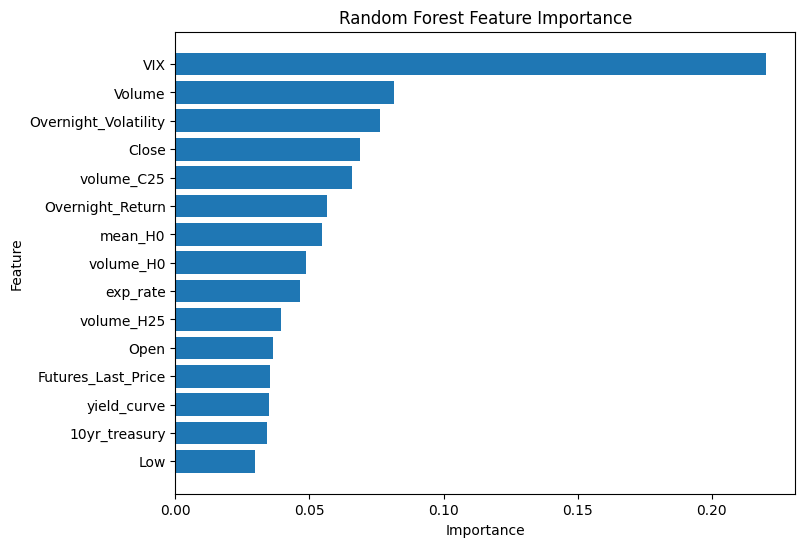

In [ ]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = random_forest_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Comparing all 5 models 

In [ ]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso", "Ridge", "Elastic Net", "Random Forest"],
        "train_mse": [train_mse, lasso_train_mse, ridge_train_mse, elastic_train_mse, random_forest_train_mse],
        "test_mse": [test_mse, lasso_test_mse, ridge_test_mse, elastic_test_mse, random_forest_test_mse],
    }
)
print(comparison_df)
comparison_df.to_csv("model_comparison.csv", index=False)

NameError: name 'train_mse' is not defined

In [ ]:
import matplotlib.pyplot as plt

results_plot = comparison_df[["model", "test_mse"]].copy()

plt.figure(figsize=(8, 5))
plt.bar(results_plot["model"], results_plot["test_mse"])
plt.xlabel("Model")
plt.ylabel("Test MSE")
plt.title("Model Comparison: Test MSE")
plt.xticks(rotation=45)
plt.show()

NameError: name 'comparison_df' is not defined